# Model Architecture - ChatKasir
- Nama: Achmad Rif'an
- Bagian: AI-1 (Model Architect)

## 1. Environment Setup

In [1]:
import os
import re
import json
import sklearn
import pandas as pd
import numpy as np
import tokenizers
import tensorflow as tf
import contextlib, io
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from collections import Counter
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.trainers import WordPieceTrainer
from tokenizers.pre_tokenizers import Whitespace
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, LayerNormalization, MultiHeadAttention, Bidirectional, LSTM
from tensorflow.keras.models import Model

# Verifikasi versi
print(f"Pandas       : {pd.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"TensorFlow   : {tf.__version__}")
print(f"Scikit-Learn : {sklearn.__version__}")
print(f"Tokenizers   : {tokenizers.__version__}")

# Check GPU
print(f"GPU tersedia: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Mount Google Drive
f = io.StringIO()
with contextlib.redirect_stdout(f):
    drive.mount('/content/drive')

print("\nDrive sudah terhubung di /content/drive")

Pandas       : 2.2.2
NumPy        : 2.0.2
TensorFlow   : 2.20.0
Scikit-Learn : 1.6.1
Tokenizers   : 0.22.2
GPU tersedia: True

Drive sudah terhubung di /content/drive


## 2. Load Dataset (Food, Slang, Sintetis)

In [2]:
# Path Utama
BASE_PATH = "/content/drive/MyDrive/ChatKasir"
DATA_PATH = f"{BASE_PATH}/assets/data"
TOKENIZER_PATH = f"{BASE_PATH}/assets/tokenizers"

# URL Dataset
url_food = "https://drive.google.com/uc?id=1Lql46klX2pEPNdHX_jJMIubla5d7fKq3"
url_slang = "https://drive.google.com/uc?id=1vZ769q0ExjO8tUa3kt_O6DPcwBub4uxc"
url_sintetis = "https://drive.google.com/uc?id=1X2o2mZkRFRfgcfsBbAJsbIyvBbx9Us2o"

df_food = pd.read_csv(url_food)
df_slang = pd.read_csv(url_slang)
df_sintetis = pd.read_csv(url_sintetis)

print(f"Total Daftar Menu: {len(df_food)} baris")
print(f"Total Kamus Slang: {len(df_slang)} baris")
print(f"Total Chat Sintetis: {len(df_sintetis)} baris")

Total Daftar Menu: 18558 baris
Total Kamus Slang: 1231 baris
Total Chat Sintetis: 100000 baris


## 3. Exploratory Data Analysis (EDA)

### 3.1 Informasi Dataset Food

In [3]:
df_food.info()

print("=" * 50)
print("\n5 Baris Pertama Dataset Food:")
df_food.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18558 entries, 0 to 18557
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    18558 non-null  object
dtypes: object(1)
memory usage: 145.1+ KB

5 Baris Pertama Dataset Food:


,name
0,abon
1,abon ayam
2,abon burger
3,abon cheese burger
4,abon goreng ayam


### 3.2 Informasi Dataset Slang

In [4]:
df_slang.info()

print("=" * 50)
print("\n5 Baris Pertama Dataset Slang:")
df_slang.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   slang   1231 non-null   object
 1   formal  1231 non-null   object
dtypes: object(2)
memory usage: 19.4+ KB

5 Baris Pertama Dataset Slang:


,slang,formal
0,aa,kakak
1,abanggg,abang
2,abanggku,abangku
3,abeees,habis
4,abes,habis


### 3.3 Informasi Dataset Sintetis

In [5]:
df_sintetis.info()

print("=" * 50)
print("\n5 Baris Pertama Dataset Sintetis:")
df_sintetis.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   input_text    100000 non-null  object
 1   product       100000 non-null  object
 2   quantity      100000 non-null  object
 3   price_satuan  100000 non-null  int64 
 4   pattern       100000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 3.8+ MB

5 Baris Pertama Dataset Sintetis:


,input_text,product,quantity,price_satuan,pattern
0,pesan nasi goreng babi setengah porsi dan kail...,nasi goreng babi & kailan daging ayam,setengah & segelas,-1,4
1,pesen nasgor sei ayam nya tiga piring porsi [S...,nasgor sei ayam,tiga piring,74000,3
2,setengah guri coffee latte pedes mampus ya kak...,guri coffee latte,setengah,21000,2
3,bu mau pesen 6 boba pedes mampus dong [SEP] ok...,boba,6,39000,2
4,mbak ayam penyet ekonomis dua sama es cendol 5...,ayam penyet ekonomis & es cendol,dua & 5,-1,4


### 3.3 Visualisasi Data

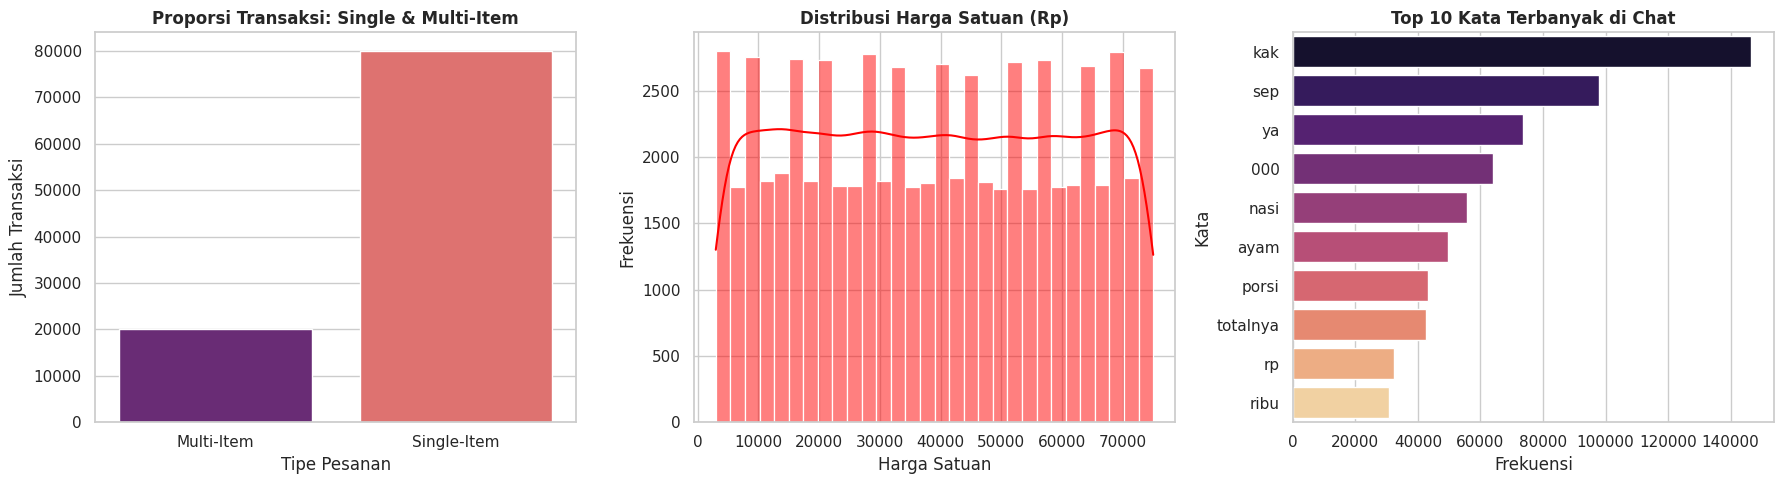

In [6]:
# Tema visual grafik
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Visualisasi Distribusi Single-Item & Multi-Item
# Mendeteksi multi-item dari keberadaan pemisah '&' pada kolom product
df_sintetis['item_count'] = df_sintetis['product'].astype(str).apply(lambda x: len(x.split('&')))
df_sintetis['order_type'] = df_sintetis['item_count'].apply(lambda x: 'Single-Item' if x == 1 else 'Multi-Item')

sns.countplot(data=df_sintetis, x='order_type', hue='order_type', palette='magma', ax=axes[0], legend=False)
axes[0].set_title('Proporsi Transaksi: Single & Multi-Item', fontweight='bold')
axes[0].set_xlabel('Tipe Pesanan')
axes[0].set_ylabel('Jumlah Transaksi')

# 2. Visualisasi Distribusi Harga Satuan
# Memfilter harga yang valid (mengabaikan -1 / harga tidak disebutkan)
valid_prices = df_sintetis[df_sintetis['price_satuan'] > 0]['price_satuan']

sns.histplot(valid_prices, bins=30, kde=True, color='red', ax=axes[1])
axes[1].set_title('Distribusi Harga Satuan (Rp)', fontweight='bold')
axes[1].set_xlabel('Harga Satuan')
axes[1].set_ylabel('Frekuensi')

# 3. Visualisasi Top 10 Kata Terbanyak
# Menggabungkan seluruh teks chat pembeli & penjual
all_text = " ".join(df_sintetis['input_text'].astype(str).tolist()).lower()
# Memecah menjadi daftar kata (menghilangkan tanda baca)
words = re.findall(r'\b\w+\b', all_text)

# Menghitung 10 kata yang paling sering muncul
top_words = Counter(words).most_common(10)
words_labels, words_counts = zip(*top_words)

sns.barplot(x=list(words_counts), y=list(words_labels), hue=list(words_labels), palette='magma', ax=axes[2], legend=False)
axes[2].set_title('Top 10 Kata Terbanyak di Chat', fontweight='bold')
axes[2].set_xlabel('Frekuensi')
axes[2].set_ylabel('Kata')

# Menampilkan grafik
plt.tight_layout()
plt.show()

## 4. Preprocessing Teks
- Menghapus timestamp dan metadata Chat WhatsApp
- Memisah chat pembeli dan penjual lalu digabungkan dengan [SEP]
- Mengonversi ke lowercase
- Mengganti simbol '&' menjadi 'dan'
- Menghapus kata sapaan
- Normalisasi teks
- Menghapus simbol yang tidak digunakan
- Menghapus kata "nya"
- Menetapkan [SEP] dalam huruf besar
- Menghapus spasi ganda

### 4.1 Buat Kamus Slang

In [7]:
kamus_slang_dict = dict(zip(df_slang['slang'].astype(str),
                            df_slang['formal'].astype(str)))

# Ubah semua key & value ke huruf kecil agar konsisten
kamus_slang_dict = {k.lower().strip(): v.lower().strip()
                    for k, v in kamus_slang_dict.items()}

print(f"Berhasil memuat {len(kamus_slang_dict)} kosakata slang")

Berhasil memuat 1231 kosakata slang


### 4.2 Fungsi Preprocessing

In [8]:
# Fungsi preprocessing chat WhatsApp
def clean_whatsapp_text(text, dict_slang):
    if not isinstance(text, str):
        return ""

    # Pisah chat per baris
    baris_chat = text.split('\n')
    baris_bersih = []

    for baris in baris_chat:
        if not baris.strip():
            continue  # lewati baris kosong

        # Jika ada tanda ':' anggap metadata -> ambil bagian kanan
        if ':' in baris:
            bagian_kiri = baris.split(':', 1)[0]
            if len(bagian_kiri) < 50:  # validasi agar tidak salah potong
                baris = baris.split(':', 1)[1]

        baris_bersih.append(baris.strip())

    # Gabungkan baris dengan pemisah [SEP]
    text = " [SEP] ".join(baris_bersih)
    text = text.replace("[SEP] [SEP]", "[SEP]")  # hindari duplikasi

    # Ubah menjadi huruf kecil semua
    text = text.lower()

    # Ubah simbol '&' menjadi 'dan'
    text = text.replace("&", " dan ")

    # Hilangkan sapaan
    sapaan_pattern = r'\b(bg|abang|bang|mas|kak|mbak|teh|aa|om|tante|bude|pakde|paklik|pak|bapak|bu|ibu|gan|sis|bro|cuy|bos|juragan|admin|halo|pagi|siang|sore|malam|assalamualaikum|wr|wb|p|ping|ass|dan|dn)\b'
    text = re.sub(sapaan_pattern, ' ', text)

    # Normalisasi teks
    text = re.sub(r'\brp\s*(\d+)', r'\1', text)  # hilangkan 'rp'
    text = re.sub(r'(?<=\d)\.(?=\d{3}\b)', '', text)  # hilangkan titik ribuan
    text = re.sub(r'\b(\d+)\s*(k|rb|ribu)\b', r'\g<1>000', text)  # ubah k/rb/ribu → 000

    # Ganti slang dengan kata formal
    kata_kata = text.split()
    kata_kata = [dict_slang.get(kata, kata) for kata in kata_kata]
    text = " ".join(kata_kata)

    # Hilangkan karakter non-alfanumerik
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)

    # Hilangkan akhiran 'nya'
    text = re.sub(r'(\b\w+)(nya)\b', r'\1', text)

    # Kecualikasn SEP
    text = text.replace("[sep]", "[SEP]")

    # Rapikan spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Uji coba
tes_input = "[07.42, 22/4/2026] Pembeli Budi: Bg pesen 2 Nasi goreng dan 3 Es kelapa ya\n[07.44, 22/4/2026] Penjual: okee kak nasi goreng harganya 10rb & es kelapa 5k jadi total harganya 35rb"
print("Input Asli   :", tes_input)
print("\nHasil Bersih :", clean_whatsapp_text(tes_input, kamus_slang_dict))


Input Asli   : [07.42, 22/4/2026] Pembeli Budi: Bg pesen 2 Nasi goreng dan 3 Es kelapa ya
[07.44, 22/4/2026] Penjual: okee kak nasi goreng harganya 10rb & es kelapa 5k jadi total harganya 35rb

Hasil Bersih : pesan 2 nasi goreng 3 es kelapa ya [SEP] okee nasi goreng harga 10000 es kelapa 5000 jadi total harga 35000


## 5. WordPiece Tokenizer

### 5.1 Bersihkan Dataset Sintetis

In [9]:
# Buat kolom baru berisi teks yang sudah lolos preprocessing bersih
df_sintetis['clean_text'] = df_sintetis['input_text'].astype(str).apply(
    lambda x: clean_whatsapp_text(x, kamus_slang_dict)
)

# Gabungkan teks chat yang sudah bersih dengan nama makanan
semua_teks_bersih = (
    df_sintetis['clean_text'].tolist() +
    df_food['name'].astype(str).str.lower().tolist()
)

### 5.2 Proses Tokenizer

In [10]:
# Inisialisasi Tokenizer WordPiece dengan token [UNK] untuk kata tak dikenal
tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()  # pisahkan kata berdasarkan spasi

# Trainer vocab 5000 untuk domain UMKM
# [PAD]: padding, [UNK]: tak dikenal, [SEP]: pemisah kalimat
trainer = WordPieceTrainer(
    vocab_size=5000,
    special_tokens=["[PAD]", "[UNK]", "[SEP]"]
)

# Latih Tokenizer menggunakan list teks yang bersih
tokenizer.train_from_iterator(semua_teks_bersih, trainer)

# Menyimpan Tokenizer
os.makedirs(TOKENIZER_PATH, exist_ok=True)
tokenizer.save(f"{TOKENIZER_PATH}/tokenizer.json")
vocab_size = tokenizer.get_vocab_size()

print(f"Tokenizer berhasil dilatih & disimpan")
print(f"Ukuran Kosakata (Vocab Size) Akhir: {vocab_size}")

Tokenizer berhasil dilatih & disimpan
Ukuran Kosakata (Vocab Size) Akhir: 5000


### 5.3 Uji Tokenizer

In [11]:
# Input uji coba
tes_chat_mentah = "[07.42, 22/4/2026] Pembeli Budi: kk mau pesen 10 daebak ken chicken wings\n[07.44] Penjual: baik kak daebak ken chicken wings harganya rp3.000 satuan"

# Teks mentah melewati preprocessing
tes_chat_bersih = clean_whatsapp_text(tes_chat_mentah, kamus_slang_dict)
print(f"1. Kalimat Masuk (Setelah Preprocessing) :\n   {tes_chat_bersih}\n")

# Konversi teks bersih menjadi token ID
hasil_encode = tokenizer.encode(tes_chat_bersih)

print(f"2. Hasil Pemotongan Menjadi Tokens :\n   {hasil_encode.tokens}\n")
print(f"3. Hasil Konversi Ke ID Angka Matriks :\n   {hasil_encode.ids}")

1. Kalimat Masuk (Setelah Preprocessing) :
   kakak ingin memesan pesan 10 daebak ken chicken wings [SEP] baik daebak ken chicken wings harga 3000 satuan

2. Hasil Pemotongan Menjadi Tokens :
   ['kakak', 'ingin', 'memesan', 'pesan', '10', 'daebak', 'ken', 'chicken', 'wings', '[SEP]', 'baik', 'daebak', 'ken', 'chicken', 'wings', 'harga', '3000', 'satuan']

3. Hasil Konversi Ke ID Angka Matriks :
   [312, 144, 145, 110, 227, 4786, 2614, 148, 422, 2, 179, 4786, 2614, 148, 422, 147, 467, 222]


## 6. Menghitung Max Length

In [12]:
# Menghitung panjang token dari kolom 'clean_text' (hasil preprocessing)
panjang_semua_teks = [
    len(tokenizer.encode(teks).ids)
    for teks in df_sintetis['clean_text'].astype(str)
]

# Cari token terpanjang dari data bersih
max_length_data = max(panjang_semua_teks)
print(f"Panjang kalimat maksimal asli setelah preprocessing : {max_length_data} token")

# Menentukan batas max_length optimal untuk arsitektur model
optimal_max_length = 128
print(f"Max Length optimal yang akan digunakan ke model  : {optimal_max_length} token")

# Memastikan angka 128 aman dan tidak memotong data penting
tercover = sum(1 for p in panjang_semua_teks if p <= optimal_max_length)
persentase = (tercover / len(panjang_semua_teks)) * 100
print(f"Persentase data yang aman pada batas 128 token  : {persentase:.2f}%")

Panjang kalimat maksimal asli setelah preprocessing : 38 token
Max Length optimal yang akan digunakan ke model  : 128 token
Persentase data yang aman pada batas 128 token  : 100.00%


## 7. Dataset Preparation

In [13]:
# Definisi Kamus Tag
tag2id = {
    "O": 0,        # Kata biasa
    "B-PROD": 1,   # Kata pertama dari nama produk
    "I-PROD": 2,   # Kata lanjutan dari nama produk
    "B-QTY": 3,    # Kata/angka pertama dari jumlah pesanan
    "I-QTY": 4,    # Kata lanjutan dari jumlah pesanan
    "B-PRICE": 5,  # Kata/angka pertama dari harga
    "I-PRICE": 6   # Kata lanjutan dari harga
}

id2tag = {id: tag for tag, id in tag2id.items()}
num_tags = len(tag2id)
print(f"Jumlah Tag (NUM_TAGS) saat ini: {num_tags}")

# Fungsi Pembuat Dataset NER
def siapkan_data_latih(df, tokenizer, max_len, dict_slang):
    """
    Mengubah data teks bersih menjadi matriks angka ID Token (X)
    dan matriks Target Label BIO Tags (Y_ner) yang selaras
    """
    X_input_ids = []
    Y_ner_tags = []

    for index, row in df.iterrows():
        # Berikan parameter dict_slang
        teks_chat = clean_whatsapp_text(str(row['input_text']), dict_slang)

        # Penanganan Multi-Item
        daftar_produk = [p.strip() for p in str(row['product']).split("&") if p.strip()]
        raw_qty = str(row['quantity'])
        daftar_qty = [q.strip() for q in raw_qty.split("&")] if raw_qty != "nan" else []

        # Tokenisasi Teks
        encoded_teks = tokenizer.encode(teks_chat).ids
        tags = [tag2id['O']] * len(encoded_teks)

        # Fungsi Penempel TAG (Sliding Window)
        def tag_entity(entity_text, tag_b, tag_i):
            if not entity_text or str(entity_text) == "nan" or str(entity_text) == "-1":
                return

            encoded_ent = tokenizer.encode(str(entity_text).lower()).ids
            panjang_ent = len(encoded_ent)
            if panjang_ent == 0:
                return

            for i in range(len(encoded_teks) - panjang_ent + 1):
                if encoded_teks[i:i+panjang_ent] == encoded_ent:
                    if tags[i] == tag2id['O']:
                        tags[i] = tag2id[tag_b]
                        for j in range(1, panjang_ent):
                            tags[i+j] = tag2id[tag_i]
                    break

        # 1. Tagging Product
        for nama_produk in daftar_produk:
            tag_entity(nama_produk, 'B-PROD', 'I-PROD')

        # 2. Tagging Quantity
        for q_str in daftar_qty:
            q_str = str(q_str).strip()
            if q_str and q_str.lower() != "nan":
                variasi_qty = []
                kamus_angka = {
                    1: ["satu", "sebiji", "seporsi", "sebungkus", "segelas", "sebotol"],
                    2: ["dua", "loro"], 3: ["tiga", "telu"], 4: ["empat", "mpat", "papat"],
                    5: ["lima", "limo"], 6: ["enam", "enem"], 7: ["tujuh", "pitu"],
                    8: ["delapan", "lapan", "wolu"], 9: ["sembilan", "songo"], 10: ["sepuluh", "sepulu"]
                }
                try:
                    qty_int = int(float(q_str))
                    variasi_qty.append(str(qty_int))
                    if qty_int in kamus_angka:
                        variasi_qty.extend(kamus_angka[qty_int])
                except ValueError:
                    variasi_qty.append(q_str.lower())

                variasi_qty.sort(key=len, reverse=True)

                for variasi in variasi_qty:
                    pencarian = re.search(r'\b' + re.escape(variasi) + r'\b', teks_chat, re.IGNORECASE)
                    if pencarian:
                        kata_ditemukan = pencarian.group(0)
                        tag_entity(kata_ditemukan, 'B-QTY', 'I-QTY')
                        break

        # 3. Tagging Harga
        # Karena harga sudah dinormalisasi menjadi angka murni (seperti 10000, 35000),
        # maka cari semua digit angka yang memiliki panjang 3 hingga 9 karakter di dalam chat bersih.
        pola_regex_harga = r'\b\d{3,9}\b'
        semua_harga_ditemukan = re.findall(pola_regex_harga, teks_chat)

        if semua_harga_ditemukan:
            semua_harga_ditemukan = list(set(semua_harga_ditemukan))
            semua_harga_ditemukan.sort(key=len, reverse=True)

            for harga_teks in semua_harga_ditemukan:
                pencarian = re.search(r'\b' + re.escape(harga_teks) + r'\b', teks_chat)
                if pencarian:
                    harga_ditemukan = pencarian.group(0)
                    tag_entity(harga_ditemukan, 'B-PRICE', 'I-PRICE')

        # Padding & Truncating
        if len(encoded_teks) > max_len:
            encoded_teks = encoded_teks[:max_len]
            tags = tags[:max_len]
        else:
            selisih = max_len - len(encoded_teks)
            id_pad = tokenizer.token_to_id("[PAD]")
            encoded_teks = encoded_teks + [id_pad] * selisih
            tags = tags + [tag2id['O']] * selisih

        X_input_ids.append(encoded_teks)
        Y_ner_tags.append(tags)

    return np.array(X_input_ids), np.array(Y_ner_tags)


# Pembuatan Dataset
X, Y_ner = siapkan_data_latih(df_sintetis, tokenizer, optimal_max_length, kamus_slang_dict)

print("\nData sudah siap untuk dilatih")
print(f"Bentuk Input Matriks (X): {X.shape}")
print(f"Bentuk Target Label NER (Y_ner): {Y_ner.shape}")

Jumlah Tag (NUM_TAGS) saat ini: 7

Data sudah siap untuk dilatih
Bentuk Input Matriks (X): (100000, 128)
Bentuk Target Label NER (Y_ner): (100000, 128)


## 8. Split Dataset (Training, Validation, Testing)

In [14]:
# Memisahkan data Training (80%) dan data sementara (20%)
X_train, X_temp, Y_ner_train, Y_ner_temp = train_test_split(
    X, Y_ner, test_size=0.20, random_state=42
)

# Membagi sisa data sementara menjadi Validation (10%) dan Testing (10%)
X_val, X_test, Y_ner_val, Y_ner_test = train_test_split(
    X_temp, Y_ner_temp, test_size=0.50, random_state=42
)

print("Hasil Pembagian Data:")
print(f"1. Training (80%): {len(X_train)} baris")
print(f"2. Validation (10%): {len(X_val)} baris")
print(f"3. Testing (10%): {len(X_test)} baris")

# Simpan semua array ke dalam file kompresi numpy (.npz)
os.makedirs(DATA_PATH, exist_ok=True)
lokasi_simpan = f"{DATA_PATH}/dataset_chatkasir.npz"

# Simpan X dan Y_ner
np.savez(lokasi_simpan,
         X_train=X_train, Y_ner_train=Y_ner_train,
         X_val=X_val, Y_ner_val=Y_ner_val,
         X_test=X_test, Y_ner_test=Y_ner_test)

print(f"\nData NER berhasil disimpan di: {lokasi_simpan}")

Hasil Pembagian Data:
1. Training (80%): 80000 baris
2. Validation (10%): 10000 baris
3. Testing (10%): 10000 baris

Data NER berhasil disimpan di: /content/drive/MyDrive/ChatKasir/assets/data/dataset_chatkasir.npz


## 9. Arsitektur Transformer + BiLSTM

In [15]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)

        # Mengabaikan padding [PAD] saat memproses data
        self.supports_masking = True

        # Multi-Head Attention: melihat hubungan antar kata
        # misal: melihat bahwa kata "2" berhubungan erat dengan kata "porsi"
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # Feed Forward Network: untuk memperdalam pemahaman makna kata
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation="relu"), Dense(embed_dim)])

        # Layer Normalization: penyeimbang agar bobot tidak meledak saat belajar
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        # Dropout: mencegah overfitting dengan mematikan sekian % saraf secara acak
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False, mask=None):
        # Membuat mask untuk mengabaikan token [PAD] yang kosong
        padding_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32) if mask is not None else None

        # Sistem attention untuk mengaitkan konteks antar kata
        attn_output = self.att(inputs, inputs, attention_mask=padding_mask)
        attn_output = self.dropout1(attn_output, training=training)

        # Residual Connection 1
        # menggabungkan pemahaman awal (inputs) dengan konteks baru (attn_output)
        out1 = self.layernorm1(inputs + attn_output)

        # Memasukkan hasil gabungan ke Feed Forward untuk diproses lebih lanjut
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        # Residual Connection 2
        # menggabungkan hasil out1 dengan hasil ffn_output, lalu distabilkan
        return self.layernorm2(out1 + ffn_output)

def build_model(vocab_size, max_length, num_tags):
    embed_dim = 128  # Dimensi embedding
    num_heads = 4    # Jumlah head attention
    ff_dim = 256     # Dimensi feed forward

    # Input Layer berupa ID token
    inputs = Input(shape=(max_length,), name="input_ids")

    # Hidden layer
    # Menangkap konteks semantik dari teks secara global
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)(inputs)  # Ubah ID jadi vektor
    x = TransformerEncoder(embed_dim, num_heads, ff_dim)(x)  # Masukkan ke Transformer Encoder
    x = TransformerEncoder(embed_dim, num_heads, ff_dim)(x)

    # BiLSTM memastikan transisi label BIO konsisten
    # return_sequences=True agar format output berdimensi 3D
    lstm_output = Bidirectional(LSTM(64, return_sequences=True))(x)

    # Unified Output Head
    # Dense Layer berukuran 7 tag menggunakan Softmax
    ner_output = Dense(num_tags, activation='softmax', name="ner_output")(lstm_output)

    # Output hanya 1 matriks
    return Model(inputs=inputs, outputs=ner_output)

# Merancang model
model = build_model(
    vocab_size=vocab_size,
    max_length=optimal_max_length,
    num_tags=num_tags
)

# Ringkasan arsitektur model
model.name = "chatkasir_model"
model.summary()

Model: "chatkasir_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │    640,000 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 128, 128)  │    330,240 │ embedding[0][0],  │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 128, 128)  │    330,240 │ transformer_enco… │
│ (TransformerEncode… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 128)  │     98,816 │ transformer_enco… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ner_output (Dense)  │ (None, 128, 7)    │        903 │ bidirectional[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,400,199 (5.34 MB)

 Trainable params: 1,400,199 (5.34 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Menyimpan Konfigurasi

In [16]:
config_model = {
    "vocab_size": vocab_size,
    "max_length": optimal_max_length,
    "num_tags": num_tags,
    "embed_dim": 128,
    "num_heads": 4,
    "ff_dim": 256
}

lokasi_config = f"{DATA_PATH}/model_config.json"
with open(lokasi_config, "w") as f:
    json.dump(config_model, f, indent=4)

print(f"Konfigurasi arsitektur berhasil disimpan di: {lokasi_config}")

Konfigurasi arsitektur berhasil disimpan di: /content/drive/MyDrive/ChatKasir/assets/data/model_config.json
